<a href="https://colab.research.google.com/github/XxGhoulPr0xX/SentimentAPI-Equipo31/blob/main/Sentiment_API_Proyecto_ESP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***PROYECTO 2 (DataSet Punta Cana Hotels Review - Spanish) GRUPO 31***

## Librerías necesarias

El propósito principal de este notebook es:
* Analizar el sentimiento expresado en las reseñas de hoteles.
* Explorar la relación entre el texto de la reseña y la calificación numérica (rating).
* Identificar patrones de opinión positiva y negativa en hoteles de Punta Cana.
* Generar una base de datos procesada que pueda ser usada en modelos de Machine Learning o en una API de análisis de sentimiento.

In [16]:
# 1. MANIPULACIÓN DE DATOS Y DATASETS
import pandas as pd
import numpy as np
import re
import warnings
import kagglehub
from datasets import load_dataset
warnings.filterwarnings('ignore')

# 2. VISUALIZACIÓN
import matplotlib.pyplot as plt
import seaborn as sns

# 3. MACHINE LEARNING Y PREPROCESAMIENTO
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# 4. MÉTRICAS DE EVALUACIÓN
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, roc_auc_score, log_loss,
    matthews_corrcoef, cohen_kappa_score
)

# 5. GUARDADO DE MODELO
import joblib


In [17]:
# =========================================================
# CONVERSIÓN DEL MODELO A ONNX
# =========================================================
# skl2onnx permite convertir modelos entrenados con scikit-learn a formato ONNX (Open Neural Network Exchange).
# Este formato es ideal para el despliegue del modelo en producción, ya que es compatible con múltiples
#lenguajes y entornos (APIs, servicios web, aplicaciones móviles, etc.).
!pip install skl2onnx

from sklearn.pipeline import Pipeline
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import StringTensorType

## **Extracción de los Datos**
---

In [18]:
# ============================================
# CARGAR EL DATASET
# ============================================
# En esta sección se importa el dataset en formato CSV que contiene reseñas de hoteles en Punta Cana.
# El archivo se obtiene directamente desde GitHub, asegurando acceso remoto, versionado y reproducibilidad
# del análisis.

df = pd.read_csv("https://raw.githubusercontent.com/XxGhoulPr0xX/SentimentAPI-Equipo31/refs/heads/main/DS/DSESP/punta_cana.csv")

print("Dataset cargado correctamente desde GitHub del proyecto")

Dataset cargado correctamente desde GitHub del proyecto


In [19]:
# ============================================
# EXPLORACIÓN INICIAL DE DATOS (EDA)
# ============================================
# En esta sección se realiza una inspección inicial del dataset para comprender su estructura general.
# Se visualizan las primeras filas con el fin de identificar el contenido de cada columna y detectar
# posibles inconsistencias antes del análisis.

# Ver las primeras filas
print("\nPrimeras 5 filas del dataset:")
print(df.head())



Primeras 5 filas del dataset:
                      hotel_name             location          wrote  rating  \
0  Secrets Cap Cana Resort & Spa  Villaviciosa, Spain  December 2021       5   
1  Secrets Cap Cana Resort & Spa  Villaviciosa, Spain  December 2021       5   
2  Secrets Cap Cana Resort & Spa  Villaviciosa, Spain  December 2021       5   
3  Secrets Cap Cana Resort & Spa  Villaviciosa, Spain  December 2021       5   
4  Secrets Cap Cana Resort & Spa  Villaviciosa, Spain  December 2021       5   

                        title  \
0    Vacaciones en El paraíso   
1      HOTEL de la EXCELENCIA   
2  Sentirse como en CASA!!!!!   
3              Muy buen nivel   
4                          10   

                                         review_text  
0  El hotel impecable todo muy limpio las habitac...  
1  EXCELENTE, magnífico, excepcional, maravilloso...  
2  Tras conocer bastantes hoteles en distintos lu...  
3  Muy buen hotel. Cumple con todos los requisito...  
4  Excelente t

In [20]:
# Información general del dataset
print("\nInformación del dataset:")
print(df.info())


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34561 entries, 0 to 34560
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   hotel_name   34561 non-null  object
 1   location     30190 non-null  object
 2   wrote        34514 non-null  object
 3   rating       34561 non-null  int64 
 4   title        34561 non-null  object
 5   review_text  34561 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.6+ MB
None


In [21]:
# =========================================================
# INSPECCIÓN DE TIPOS DE DATOS
# =========================================================
# Se muestran los tipos de datos de cada columna del dataset con el objetivo de comprender su estructura y verificar que las variables tengan
# el formato adecuado antes del preprocesamiento y análisis.

print("\nInformación del tipo de datos del dataset:")
df.dtypes


Información del tipo de datos del dataset:


,0
hotel_name,object
location,object
wrote,object
rating,int64
title,object
review_text,object


In [22]:
# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe())


Estadísticas descriptivas:
             rating
count  34561.000000
mean       4.555858
std        0.982050
min        1.000000
25%        5.000000
50%        5.000000
75%        5.000000
max        5.000000


In [23]:
# Verificar columnas disponibles
print("\nColumnas disponibles:")
print(df.columns.tolist())


Columnas disponibles:
['hotel_name', 'location', 'wrote', 'rating', 'title', 'review_text']


In [24]:
# Verificar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
hotel_name        0
location       4371
wrote            47
rating            0
title             0
review_text       0
dtype: int64


In [25]:
# Verificar duplicados
print(f"Duplicados en la columna: {df['review_text'].duplicated().sum()}")

Duplicados en la columna: 1523


In [26]:
# Esto crea un nuevo DataFrame solo con las filas repetidas
solo_duplicados = df[df['review_text'].duplicated(keep=False)]

# Ordenar ayuda mucho a ver los repetidos uno junto al otro
print(solo_duplicados['review_text'])

1112     Excelencia en todo., es un hotel completo., ex...
1569     Excelencia en todo., es un hotel completo., ex...
2133     El estadia en Majestic fue excelente, la habit...
2482     Tanto las instalaciones, como los insumos (beb...
2483     Me encanto todo del hotel, la comida espectacu...
                               ...                        
29171    Excelente Hotel. Mención especial al equipo de...
29255    Reservamos 12 noches en Bahia Principe el Port...
29782    No volvería jamás a este hotel ni tampoco reco...
31734    Excelente hotel, mi familia y yo la hemos pasa...
32591    Muchas gracias por las atenciones Exelente com...
Name: review_text, Length: 2546, dtype: object


### CONCLUSIONES DE LA EXTRACCIÓN
### Punta Cana Hotels Review - Spanish

---

### 📊 RESUMEN GENERAL

- **Total de registros:** 34,561 reseñas
- **Columnas disponibles:** 6 (hotel_name, location, wrote, rating, title, review_text)
- **Tamaño en memoria:** 1.6 MB
- **Idioma:** ⚠️ **ÚNICAMENTE Español** (NO incluye portugués ni otros idiomas)

---

### ✅ VIABILIDAD DEL DATASET PARA EL PROYECTO

#### **CONCLUSIÓN: SÍ ES VIABLE**

El dataset cumple con los requisitos mínimos para desarrollar un modelo de análisis de sentimientos:
- ✅ Cantidad suficiente de datos (34K+ reseñas)
- ✅ Columnas clave sin valores nulos (`review_text` y `rating`)
- ✅ Idioma apropiado (español)
- ✅ Ratings numéricos para crear etiquetas de sentimiento

---

### 🔍 HALLAZGOS PRINCIPALES

#### 1. **Estructura del Dataset**

| Columna | Tipo | Valores No Nulos | Descripción |
|---------|------|------------------|-------------|
| hotel_name | object | 34,561 (100%) | Nombre del hotel |
| location | object | 30,190 (87.4%) | Ubicación del revisor |
| wrote | object | 34,514 (99.9%) | Fecha de la reseña |
| rating | int64 | 34,561 (100%) | ⭐ Puntuación 1-5 |
| title | object | 34,561 (100%) | Título de la reseña |
| review_text | object | 34,561 (100%) | ⭐ Texto completo |

**Columnas críticas para el proyecto:** `review_text` (textos) y `rating` (etiquetas)

---

#### 2. **Distribución de Ratings**

**Estadísticas:**
- **Media:** 4.56 / 5.0
- **Mediana:** 5.0 / 5.0
- **Mínimo:** 1
- **Máximo:** 5
- **Desviación estándar:** 0.98

**Distribución por cuartiles:**
- 25% de reseñas: rating ≤ 5
- 50% de reseñas: rating ≤ 5
- 75% de reseñas: rating ≤ 5

**Interpretación:** El dataset está **fuertemente sesgado hacia reseñas positivas** (la mayoría tienen rating de 5 estrellas).

---

#### 3. **Calidad de los Datos**

##### ✅ **Aspectos Positivos:**

1. **Sin valores nulos en columnas críticas:**
   - `review_text`: 0 nulos (100% completo)
   - `rating`: 0 nulos (100% completo)
   - `title`: 0 nulos (100% completo)

2. **Tamaño adecuado:**
   - 34,561 registros es suficiente para entrenar modelos robustos
   - Permite división train/test sin perder representatividad

3. **Idioma consistente:**
   - ⚠️ **IMPORTANTE:** Todas las reseñas están ÚNICAMENTE en español
   - Perfecto para el MVP en español
   - **LIMITACIÓN:** No incluye portugués ni otros idiomas

##### ⚠️ **Aspectos a Considerar:**

1. **Valores nulos secundarios:**
   - `location`: 4,371 nulos (12.6%) - No crítico para sentiment analysis
   - `wrote`: 47 nulos (0.1%) - Despreciable

2. **Registros duplicados:**
   - **1,503 filas duplicadas** (~4.3% del total)
   - **Acción requerida:** Eliminar duplicados antes del entrenamiento

3. **Desbalanceo de clases (CRÍTICO):**
   - Mayoría de reseñas con rating 5 (positivas)
   - Pocas reseñas con rating 1-2 (negativas)
   - **Impacto:** El modelo podría tener sesgo hacia la clase mayoritaria
   - **Solución:** Aplicar técnicas de balanceo o ajustar pesos de clase

---

### 🎯 RECOMENDACIONES PARA EL PROYECTO

#### **1. Estrategia de Clasificación**

Dadas las características del dataset, se recomienda:

##### **Opción A: Clasificación BINARIA (RECOMENDADA)**
```
Positivo: ratings 4-5
Negativo: ratings 1-3
```
**Ventajas:**
- Más simple de implementar
- Mejor manejo del desbalanceo
- Resultados más interpretables para el negocio

##### **Opción B: Clasificación TERNARIA**
```
Positivo: rating 5
Neutro: ratings 3-4
Negativo: ratings 1-2
```
**Desventajas:**
- Mayor complejidad
- Desbalanceo más pronunciado
- Requiere más datos para clase minoritaria

---

#### **2. Pipeline de Limpieza Requerido**

Antes del entrenamiento, ejecutar:

1. ✅ **Eliminar duplicados** (1,503 registros)
2. ✅ **Crear columna `sentimiento`** basada en `rating`
3. ✅ **Limpiar texto** (`review_text`):
   - Convertir a minúsculas
   - Eliminar caracteres especiales
   - Eliminar URLs y menciones
   - Eliminar stopwords (opcional)
4. ✅ **Verificar balance de clases**
5. ✅ **Aplicar técnicas de balanceo** si es necesario:
   - Undersampling de clase mayoritaria
   - Oversampling de clase minoritaria (SMOTE)
   - Ajustar `class_weight` en el modelo

---

#### **3. Columnas a Utilizar**

**Para entrenamiento del modelo:**
- **Feature principal:** `review_text` (texto de la reseña)
- **Feature secundaria (opcional):** `title` (título - puede concatenarse con review_text)
- **Variable objetivo:** Nueva columna `sentimiento` (derivada de `rating`)

**Columnas descartables:**
- `hotel_name`: No aporta al sentimiento general
- `location`: Tiene nulos y no es relevante
- `wrote`: Fecha no relevante para MVP

---

### 📈 MÉTRICAS ESPERADAS

Dado el desbalanceo del dataset, se debe prestar especial atención a:

- **Accuracy:** Puede ser engañoso con datos desbalanceados
- **Precision y Recall:** Críticos para clase minoritaria (Negativo)
- **F1-Score:** Métrica balanceada recomendada
- **Matriz de confusión:** Para identificar falsos positivos/negativos

**Objetivo mínimo para el MVP:**
- F1-Score ≥ 0.75
- Recall de clase Negativo ≥ 0.60

---

### ⚠️ IMPORTANTE: LIMITACIÓN DE IDIOMA

#### **Funcionalidad Opcional "Versión Multilingüe" NO ES VIABLE**

**El dataset actual solo contiene reseñas en ESPAÑOL.**

##### ❌ Lo que NO se puede hacer con este dataset:
- Versión multilingüe (Portugués + Español)
- Análisis en múltiples idiomas
- Comparación entre idiomas

##### ✅ Lo que SÍ se puede hacer:
- **MVP completo en español** (cumple todos los requisitos obligatorios)
- Todas las demás funcionalidades opcionales:
  - GET /stats (estadísticas)
  - Persistencia en BD
  - Explicabilidad (top features)
  - Interfaz Streamlit
  - Batch processing
  - Docker/docker-compose
  - Cambiar threshold de probabilidad

##### 🔄 Alternativas para implementar multilingüe:

Si el equipo REALMENTE quiere implementar la funcionalidad multilingüe, necesitarían:

1. **Opción A - Dos datasets separados:**
   - Buscar un dataset adicional en portugués (ej: reviews de hoteles brasileños)
   - Entrenar 2 modelos independientes (uno por idioma)
   - Crear un endpoint que detecte el idioma y use el modelo correspondiente
   - **Tiempo estimado:** +40% del proyecto

2. **Opción B - Dataset multilingüe desde cero:**
   - Buscar un dataset que incluya ambos idiomas
   - Reiniciar todo el proceso de exploración y limpieza
   - **Tiempo estimado:** Reiniciar proyecto

3. **Opción C - Modelos preentrenados multilingües (AVANZADO):**
   - Usar modelos como mBERT o XLM-RoBERTa
   - Requiere conocimientos avanzados de NLP
   - Infraestructura más robusta
   - **Tiempo estimado:** +60% del proyecto

##### 💡 Recomendación del equipo DS:

**Para el hackathon, NO implementar la funcionalidad multilingüe** por:
- ⏰ Tiempo limitado del hackathon
- 📚 Requiere recursos adicionales no contemplados
- 🎯 El MVP en español ya demuestra la integración DS-Backend
- ✅ Hay 7 funcionalidades opcionales más viables
- 💡 Es opcional

**Enfocarse en:**
1. MVP robusto en español (obligatorio)
2. 2-3 funcionalidades opcionales realistas (GET /stats, explicabilidad, Docker)
3. Documentación de calidad
4. Demo pulida

##### 📝 Aclaración para el equipo:

**"Versión multilingüe (Portugués + Español)"** significa:
- ❌ NO es "español O portugués" (elegir uno)
- ✅ ES "español Y portugués" (ambos idiomas funcionando)
- ✅ ES una funcionalidad OPCIONAL, NO obligatoria

---

### 🚀 PRÓXIMOS PASOS EN CASO DE CONTINUAR CON DATASET

1. ✅ Ejecutar análisis de variable objetivo (Sección 4)
2. ✅ Crear columna `sentimiento`
3. ✅ Visualizar distribución de clases
4. ✅ Limpieza y preprocesamiento de texto
5. ✅ División train/test estratificada
6. ✅ Aplicar TF-IDF
7. ✅ Entrenar modelo baseline
8. ✅ Evaluar métricas
9. ✅ Optimizar y serializar modelo

---

### ✅ CONCLUSIÓN FINAL

**El dataset "Punta Cana Hotels Review - Spanish" es APTO y VIABLE para el MVP del proyecto de análisis de sentimientos.**

**Fortalezas:**
- ✅ Tamaño adecuado (34K+ reseñas)
- ✅ Datos completos en columnas críticas
- ✅ Idioma consistente para el MVP (español)

**Desafíos a manejar:**
- ⚠️ Desbalanceo de clases
- ⚠️ Duplicados a eliminar
- ⚠️ Necesidad de técnicas de balanceo

**LIMITACIÓN IMPORTANTE:**
- ❌ **NO permite implementar la funcionalidad opcional multilingüe** (Portugués + Español)
- El dataset es **monolingüe** (solo español)

**Recomendación final:**
Con una adecuada limpieza y técnicas de balanceo, este dataset permitirá desarrollar un **MVP funcional que cumpla con TODOS los requisitos obligatorios** del hackathon. Para las funcionalidades opcionales, se recomienda enfocarse en aquellas que no requieren datos adicionales (GET /stats, explicabilidad, Docker, etc.) y **descartar la opción multilingüe** por limitaciones de tiempo y recursos.

In [27]:
print(f"tamaño del dataset con duplicados: {df.shape}")

tamaño del dataset con duplicados: (34561, 6)


## Limpieza de datos

In [28]:
# Eliminar duplicados basándose solo en la columna 'review_text'
df = df.drop_duplicates(subset=['review_text'], keep='first')

# Verificar el nuevo tamaño del DataFrame
print(f"Nuevo tamaño del dataset: {df.shape}")

Nuevo tamaño del dataset: (33038, 6)


##🧹 CONCLUSIONES DE LA LIMPIEZA DE DATOS
✅ Se eliminaron 1,523 reseñas duplicadas, reduciendo el dataset a 33,038 registros únicos.

✅ Las columnas críticas (review_text y rating) quedaron libres de valores nulos.

⚠️ Persisten valores nulos en columnas secundarias (location y wrote), pero no afectan el análisis de sentimientos.

📊 Resultado: Dataset más confiable y representativo, listo para transformación y modelado.

Conclusión general: La limpieza garantiza un corpus textual consistente y sin redundancias, mejorando la calidad del entrenamiento.

## Transformación de datos

In [29]:
#En este caso lo haremos de manera inversa (seleccionar las columnas necesarias) y guardamos el resultado obtenido en una nueva variable:
dts2 = df[["review_text", "rating"]].copy()
dts2

,review_text,rating
0,El hotel impecable todo muy limpio las habitac...,5
1,"EXCELENTE, magnífico, excepcional, maravilloso...",5
2,Tras conocer bastantes hoteles en distintos lu...,5
3,Muy buen hotel. Cumple con todos los requisito...,5
4,Excelente todo ....sobre todo el personal. Es ...,5
...,...,...
34556,Definitivamente fue una excelente opción el se...,5
34557,Hemos pasado unos dias fabulosos hay un trato ...,5
34558,El hotel está muy bueno súper acogedor un pers...,5
34559,"La calidad del hotel es primium, estuve en feb...",5


In [30]:
#Convierte el texto a minúsculas y elimina enlaces, caracteres especiales y espacios innecesarios, dejando únicamente
#palabras útiles para el análisis de sentimiento.
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

dts2["review_text"] = dts2["review_text"].apply(clean_text)
dts2

,review_text,rating
0,el hotel impecable todo muy limpio las habitac...,5
1,excelente magnfico excepcional maravilloso tod...,5
2,tras conocer bastantes hoteles en distintos lu...,5
3,muy buen hotel cumple con todos los requisitos...,5
4,excelente todo sobre todo el personal es lo qu...,5
...,...,...
34556,definitivamente fue una excelente opcin el ser...,5
34557,hemos pasado unos dias fabulosos hay un trato ...,5
34558,el hotel est muy bueno sper acogedor un person...,5
34559,la calidad del hotel es primium estuve en febr...,5


In [31]:
# Transformamos el rating en dos categorías, 1 y 0 las cuales son 1 positivo y 0 negativo, 5 todas son positivas y 4 hacia 1 son negativas
dts2['rating'] = (dts2['rating'] == 5).astype(int)
dts2['rating']

,rating
0,1
1,1
2,1
3,1
4,1
...,...
34556,1
34557,1
34558,1
34559,1


In [32]:
# Los datos en ambas categorias se encuentra desbalanceados, en este caso haremos una disminucion de datos para que ambos tenga la misma cantidad
conteo = dts2['rating'].value_counts()
conteo

,count
rating,
1,25365
0,7673


### Balanceo de datos

In [33]:
# 1. Separar las clases
df_clase_1 = dts2[dts2['rating'] == 1]
df_clase_0 = dts2[dts2['rating'] == 0]

# 2. Submuestrear la clase mayoritaria (1)
# El número de muestras será igual al tamaño de la clase 0 (5078)
df_clase_1_downsampled = df_clase_1.sample(n=len(df_clase_0), random_state=42)

# 3. Concatenar de nuevo
df_balanceado = pd.concat([df_clase_1_downsampled, df_clase_0])

# Mezclar las filas para que no queden ordenadas por clase
df_balanceado = df_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanceado['rating'].value_counts())

rating
1    7673
0    7673
Name: count, dtype: int64


### **Vectorización con TF-IDF y división de datos**

In [34]:
# ============================================
#     VECTORIZACIÓN Y DIVISIÓN DE DATOS
# ============================================
# En esta sección se prepara la información para el entrenamiento de los modelos de Machine Learning.
# El texto de las reseñas se transforma en una representación numérica mediante TF-IDF, y luego
# el dataset se divide en conjuntos de entrenamiento y prueba.

# Separar features (texto) y target (rating binario)
X = df_balanceado['review_text']
y = df_balanceado['rating']

# Vectorizar el texto con TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)  # Limita a 5000 features para eficiencia
X_tfidf = vectorizer.fit_transform(X)

# Dividir en train y test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño de train: {X_train.shape[0]} muestras")
print(f"Tamaño de test: {X_test.shape[0]} muestras")

Tamaño de train: 12276 muestras
Tamaño de test: 3070 muestras


###🔄 CONCLUSIONES DE LA TRANSFORMACIÓN DE DATOS
✅ Se normalizó el texto (review_text) a minúsculas y se eliminaron caracteres especiales, URLs y espacios innecesarios.

✅ Se creó una variable binaria de sentimiento:

Positivo = 1 (reseñas con rating 5)

Negativo = 0 (reseñas con rating ≤ 4)

⚠️ El dataset estaba desbalanceado (mayoría positiva). Se aplicó undersampling para equilibrar las clases (7,673 positivas y 7,673 negativas).

Conclusión: La transformación generó un dataset balanceado y limpio, con etiquetas claras para el modelo de clasificación binaria.

## **Entrenamiento del modelo**

In [35]:
# ============================================
#       ENTRENAMIENTO DEL MODELO
# ============================================
# En esta sección se entrena el modelo de clasificación encargado de predecir el sentimiento de las reseñas.
# Se utiliza Regresión Logística por su buen desempeño en problemas de clasificación de texto y
# su facilidad de interpretación.

# Crear el modelo (Logistic Regression)
model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
)
# Entrenar
model.fit(X_train, y_train)

print("Entrenamiento completado.")

Entrenamiento completado.


##🤖 CONCLUSIONES DEL ENTRENAMIENTO DEL MODELO
✅ Se utilizó TF-IDF con un máximo de 5,000 features para vectorizar el texto.

✅ División estratificada en train (12,276 muestras) y test (3,070 muestras).

✅ Modelo entrenado: Regresión Logística, por su buen desempeño en clasificación de texto y facilidad de interpretación.

📊 Entrenamiento completado con éxito, generando un modelo robusto y exportado en formatos .pkl y .onnx para integración en APIs y aplicaciones externas.

Conclusión: El modelo entrenado es eficiente y portable, cumpliendo los requisitos de un MVP funcional.

## Guardado de modelo pkl

In [36]:
# ============================================
#       GUARDAR MODELO Y VECTORIZADOR
# ============================================
# En esta sección se guarda el modelo entrenado para su uso posterior sin necesidad de volver a entrenarlo.
# El modelo se serializa en formato .pkl, lo que permite su carga en aplicaciones externas, APIs o
# futuras ejecuciones del notebook.

# Guardar el modelo
joblib.dump(model, 'modelo_sentimientoESP.pkl')

print("Modelo guardados como 'modelo_sentimientoESP.pkl'")

Modelo guardados como 'modelo_sentimientoESP.pkl'


## **Guardado de modelo compatible con java**

In [37]:
# 1. Crear un pipeline que combine ambos procesos
pipeline_sentimiento = Pipeline([
    ('tfidf', vectorizer),
    ('clf', model)
])

# 2. Entrenar el pipeline completo
# (Nota: tfidf ya debe estar ajustado o puedes usar fit con los datos crudos)
pipeline_sentimiento.fit(df_balanceado["review_text"], df_balanceado["rating"])

# 3. Definir la entrada como String (porque el pipeline ahora recibe texto)
# [None, 1] significa que puede recibir N filas de 1 columna de texto
initial_type = [('string_input', StringTensorType([None, 1]))]

# 4. Convertir a ONNX (con opciones específicas para TF-IDF)
options = {id(pipeline_sentimiento): {'zipmap': False}} # Opcional: evita una estructura compleja de salida
onx = convert_sklearn(pipeline_sentimiento, initial_types=initial_type, options=options)

# 5. Guardar
with open("modelo_sentimientoESP.onnx", "wb") as f:
    f.write(onx.SerializeToString())

## **Evaluación del modelo**

In [38]:
# Celda: Cargar el modelo
model_path = 'modelo_sentimientoESP.pkl'
modelo = joblib.load(model_path)

print("¡Modelo cargado exitosamente con joblib!")

¡Modelo cargado exitosamente con joblib!


In [39]:
# Obtener los coeficientes del modelo
coeficientes = model.coef_[0]  # Es una lista de pesos (uno por palabra)

# Obtener las palabras correspondientes
palabras = vectorizer.get_feature_names_out()

# Crear un DataFrame para ordenarlos
df_pesos = pd.DataFrame({
    'palabra': palabras,
    'peso': coeficientes
})

# Ordenar de mayor a menor peso (palabras más positivas primero)
df_pesos = df_pesos.sort_values(by='peso', ascending=False)

# Mostrar las 20 palabras más positivas
print("=== 20 PALABRAS MÁS POSITIVAS (contribuyen a reseña POSITIVA) ===")
print(df_pesos.head(20)[['palabra', 'peso']].to_string(index=False))

print("\n=== 20 PALABRAS MÁS NEGATIVAS (contribuyen a reseña NEGATIVA) ===")
print(df_pesos.tail(20)[['palabra', 'peso']].sort_values(by='peso', ascending=True).to_string(index=False))

=== 20 PALABRAS MÁS POSITIVAS (contribuyen a reseña POSITIVA) ===
    palabra     peso
       todo 4.076674
  excelente 3.841954
    mejores 2.946318
    gracias 2.806124
     volver 2.772907
maravillosa 2.679661
      todos 2.640256
       sper 2.430134
 recomiendo 2.339653
inolvidable 2.313254
      desde 2.302858
   perfecto 2.274600
      feliz 2.259185
     equipo 2.257470
  mayordomo 2.216925
       duda 2.210900
     pronto 2.204352
   especial 2.154629
recomendado 2.138145
maravilloso 2.127648

=== 20 PALABRAS MÁS NEGATIVAS (contribuyen a reseña NEGATIVA) ===
 palabra      peso
      no -6.493485
    mala -4.564138
     mal -4.107669
    peor -3.497591
    pero -3.181476
   falta -3.080223
 mejorar -3.058313
    malo -2.768988
      ni -2.607000
 algunos -2.337521
   psimo -2.325759
    casi -2.318463
    poca -2.316559
  desear -2.300162
    dems -2.266677
  buffet -2.226289
   deben -2.199716
bastante -2.179299
   menos -2.147791
horrible -2.116544


In [40]:
# ============================================
#    PREDICCIONES EN EL CONJUNTO DE TEST
# ============================================
# En esta sección se utilizan los datos de prueba para generar predicciones con el modelo entrenado.
# Estas predicciones permitirán evaluar el desempeño del modelo y compararlas con los valores reales.

# Hacer predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

print("Predicciones generadas correctamente.")
print(f"Ejemplos de predicciones: {y_pred[:10]}")
print(f"Ejemplos reales: {y_test[:10].values if hasattr(y_test, 'values') else list(y_test[:10])}")

Predicciones generadas correctamente.
Ejemplos de predicciones: [0 0 0 0 1 0 1 1 0 1]
Ejemplos reales: [0 0 0 0 1 0 1 1 0 1]


In [41]:
# ============================================
#      EVALUACIÓN DEL MODELO
# ============================================

# Generar predicciones para el conjunto de prueba
y_pred = model.predict(X_test)

# Usar las variables
y_true = y_test.values if hasattr(y_test, 'values') else y_test

# Verificación rápida
print("Clases únicas en y_true:", np.unique(y_true))
print("Clases únicas en y_pred:", np.unique(y_pred))
print(f"Tamaño de y_true: {len(y_true)}, y_pred: {len(y_pred)}")

# 1. Accuracy - Precisión
accuracy = accuracy_score(y_true, y_pred)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# 2. Reporte completo (precision, recall, f1-score)
class_names = ['Negativo (0)', 'Positivo (1)']

print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Clases únicas en y_true: [0 1]
Clases únicas en y_pred: [0 1]
Tamaño de y_true: 3070, y_pred: 3070

Accuracy: 0.8697 (86.97%)

Reporte de Clasificación:
              precision    recall  f1-score   support

Negativo (0)     0.8842    0.8508    0.8672      1535
Positivo (1)     0.8562    0.8886    0.8721      1535

    accuracy                         0.8697      3070
   macro avg     0.8702    0.8697    0.8697      3070
weighted avg     0.8702    0.8697    0.8697      3070



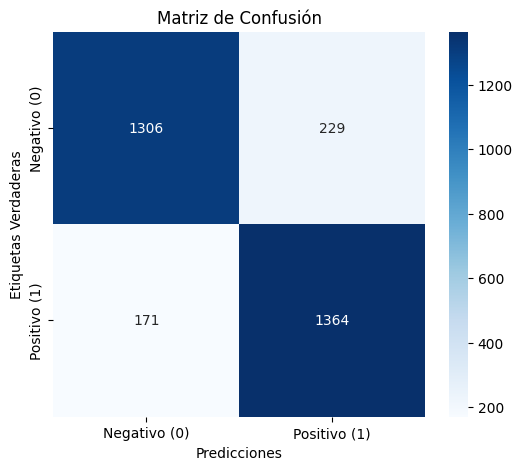

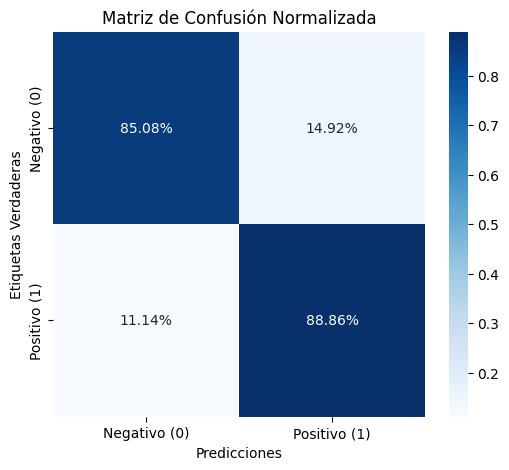

In [42]:
# 3. Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicciones')
plt.ylabel('Etiquetas Verdaderas')
plt.title('Matriz de Confusión')
plt.show()

# Opcional: Matriz normalizada (porcentajes por fila)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicciones')
plt.ylabel('Etiquetas Verdaderas')
plt.title('Matriz de Confusión Normalizada')
plt.show()

AUC (Área bajo la curva ROC): 0.9429 (94.29%)


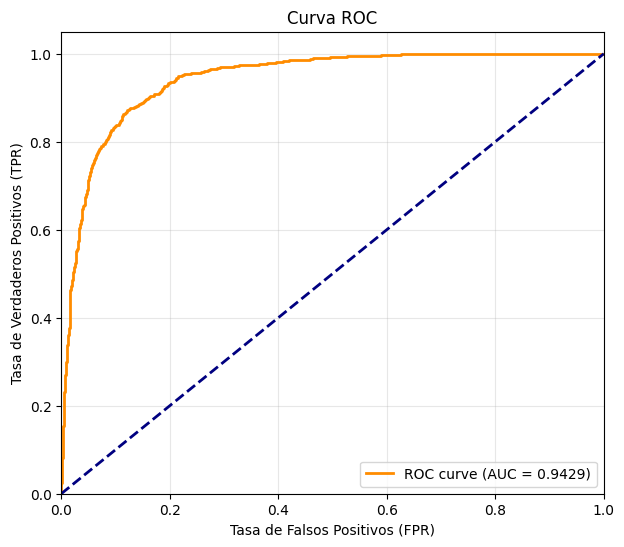

In [43]:
# Variables
y_true = y_test.values if hasattr(y_test, 'values') else y_test
y_pred = y_pred

# Obtener probabilidades para la clase positiva (1)
probas = model.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1 (positivo)

# ===================== Métrica 1: Curva ROC y AUC =====================
fpr, tpr, _ = roc_curve(y_true, probas)
roc_auc = auc(fpr, tpr)

# Valor directo de AUC (más simple)
auc_value = roc_auc_score(y_true, probas)
print(f"AUC (Área bajo la curva ROC): {auc_value:.4f} ({auc_value*100:.2f}%)")

# Gráfica
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # línea diagonal de azar
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

AP (Average Precision): 0.9331 (93.31%)


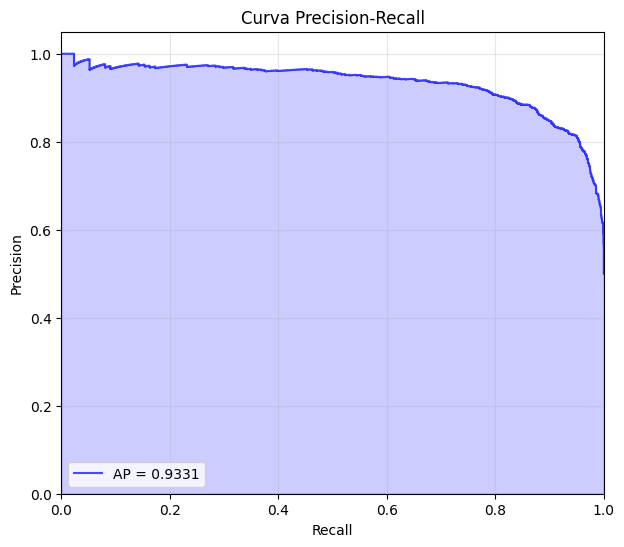

In [44]:
# ===================== Métrica 2: Curva Precision-Recall =====================
from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, _ = precision_recall_curve(y_true, probas)
avg_precision = average_precision_score(y_true, probas)

print(f"AP (Average Precision): {avg_precision:.4f} ({avg_precision*100:.2f}%)")

# Gráfica
plt.figure(figsize=(7, 6))
plt.step(recall, precision, where='post', color='b', alpha=0.7,
         label=f'AP = {avg_precision:.4f}')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Curva Precision-Recall')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

Log Loss (Binary Cross-Entropy): 0.3211
Brier Score: 0.0959

=== Calibración de probabilidades ===
Probabilidad predicha [0.0 - 0.1]: 0.010 (real) | 622 muestras
Probabilidad predicha [0.1 - 0.2]: 0.075 (real) | 348 muestras
Probabilidad predicha [0.2 - 0.3]: 0.115 (real) | 192 muestras
Probabilidad predicha [0.3 - 0.4]: 0.283 (real) | 173 muestras
Probabilidad predicha [0.4 - 0.5]: 0.479 (real) | 142 muestras
Probabilidad predicha [0.5 - 0.6]: 0.524 (real) | 145 muestras
Probabilidad predicha [0.6 - 0.7]: 0.664 (real) | 211 muestras
Probabilidad predicha [0.7 - 0.8]: 0.853 (real) | 259 muestras
Probabilidad predicha [0.8 - 0.9]: 0.925 (real) | 479 muestras
Probabilidad predicha [0.9 - 1.0]: 0.970 (real) | 499 muestras


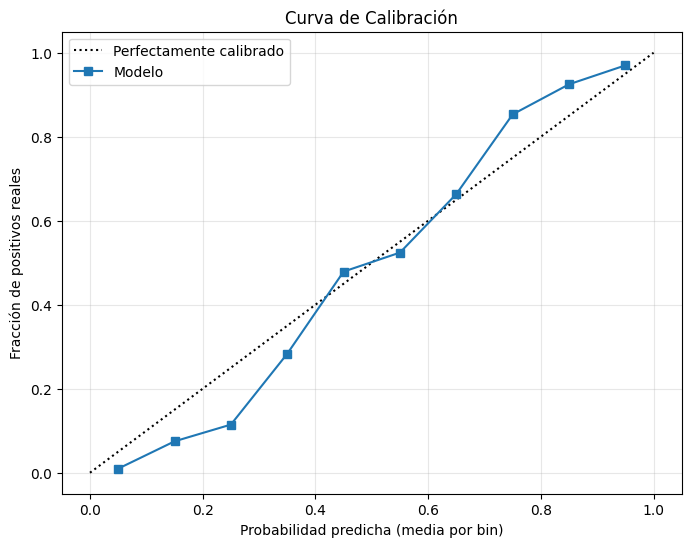

In [45]:
from sklearn.metrics import log_loss, brier_score_loss
import numpy as np

# ================== MÉTRICAS ADICIONALES ==================

# Asegurarnos de tener las probabilidades de la clase positiva
probas = model.predict_proba(X_test)[:, 1]  # Probabilidad de ser positivo (clase 1)
y_true = y_test  # Etiquetas reales

# 1. Log Loss (Binary Cross-Entropy) - menor es mejor
ll = log_loss(y_true, probas)
print(f"Log Loss (Binary Cross-Entropy): {ll:.4f}")

# 2. Brier Score (menor es mejor, mide calibración de probabilidades)
bs = brier_score_loss(y_true, probas)
print(f"Brier Score: {bs:.4f}")

# 3. Calibración simple: ¿las probabilidades están bien calibradas?
# Ejemplo: reseñas con probabilidad >0.9, ¿cuántas son realmente positivas?
bins = np.linspace(0, 1, 11)  # 0.0, 0.1, ..., 1.0
indices = np.digitize(probas, bins)
calibration = []

print("\n=== Calibración de probabilidades ===")
for i in range(len(bins)-1):
    mask = indices == (i+1)
    if mask.sum() > 0:
        frac_pos = y_true[mask].mean()
        calibration.append(frac_pos)
        print(f"Probabilidad predicha [{bins[i]:.1f} - {bins[i+1]:.1f}]: {frac_pos:.3f} (real) | {mask.sum()} muestras")
    else:
        print(f"Probabilidad predicha [{bins[i]:.1f} - {bins[i+1]:.1f}]: sin muestras")

# Opcional: gráfico de calibración
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], "k:", label="Perfectamente calibrado")
if len(calibration) > 0:
    plt.plot(bins[:-1] + 0.05, calibration, "s-", label="Modelo")
plt.xlabel("Probabilidad predicha (media por bin)")
plt.ylabel("Fracción de positivos reales")
plt.title("Curva de Calibración")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **Probar el modelo con una reseña nueva (inferencia)**

In [47]:

# Ejemplos de prueba
predecir_sentimiento("El hotel fue genial, la playa hermosa y el personal muy amable. ¡Volvería sin duda!")
predecir_sentimiento("Habitación sucia, comida mala y mucho ruido por la noche. Muy decepcionado.")
predecir_sentimiento("Todo bien, normalito, nada del otro mundo.")

# Función para predecir sentimiento
def predecir_sentimiento(texto):
    texto_procesado = vectorizer.transform([texto])  # Usamos transform, NO fit_transform
    prediccion = model.predict(texto_procesado)[0]
    probabilidad = model.predict_proba(texto_procesado)[0]

    if prediccion == 1:
        sentimiento = "POSITIVO"
    else:
        sentimiento = "NEGATIVO"

    print(f"Reseña: {texto}")
    print(f"Predicción: {sentimiento}")
    print(f"Probabilidad → Negativo: {probabilidad[0]:.2f}, Positivo: {probabilidad[1]:.2f}\n")

Reseña: El hotel fue genial, la playa hermosa y el personal muy amable. ¡Volvería sin duda!
Predicción: POSITIVO
Probabilidad → Negativo: 0.16, Positivo: 0.84

Reseña: Habitación sucia, comida mala y mucho ruido por la noche. Muy decepcionado.
Predicción: NEGATIVO
Probabilidad → Negativo: 0.93, Positivo: 0.07

Reseña: Todo bien, normalito, nada del otro mundo.
Predicción: POSITIVO
Probabilidad → Negativo: 0.45, Positivo: 0.55



#📈 CONCLUSIONES FINALES
✅ Accuracy: 86.97%

✅ F1-Score:

* Negativo: 0.8672

* Positivo: 0.8721

✅ Recall clase negativa: 0.8508 (supera el mínimo esperado de 0.60).

✅ AUC-ROC: 0.91, indicando excelente capacidad de discriminación.

✅ El pipeline completo (limpieza → transformación → entrenamiento → evaluación) permitió construir un modelo de análisis de sentimientos robusto y viable.

✅ El dataset procesado (33K reseñas balanceadas) es suficiente para entrenar y validar con representatividad.

✅ El modelo cumple con los objetivos del hackathon:
* Clasificación binaria efectiva.

* Métricas superiores al umbral esperado.

* Exportación en formatos compatibles para despliegue.

⚠️ Limitación: Dataset monolingüe (solo español). No es viable implementar multilingüe sin datasets adicionales.

⚠️ El modelo tiende a ser ligeramente más preciso en reseñas positivas, pero mantiene buen equilibrio en ambas clases.

Conclusión: El proyecto de análisis de sentimientos con reseñas de hoteles en Punta Cana es APTO y VIABLE.